# Plummer Sphere Stability Test — nbody\_streams GPU Tree

Simulates an isolated Plummer cluster in realistic units **(kpc, km/s, M☉)**
using the  low-level integrator with .

| Unit | Value |
|------|-------|
| length | 1 kpc |
| velocity | 1 km/s |
| mass | 1 M☉ |
| time | 1 kpc/(km/s) ≈ 0.978 Gyr |
| G | 4.3009 × 10⁻⁶ kpc (km/s)² M☉⁻¹ |

**Integration:** KDK leapfrog (half-kick → drift → force → half-kick).  
**Diagnostics:**  appends virial ratio Q and ΔE/E to every progress line  
(potential φ is returned for free by each tree force call — no extra cost).  
**Post-run:** All 300 snapshots are loaded via ; energy reconstructed with .


In [1]:
import os
import time
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

# nbody_streams GPU tree integrator + public API
from nbody_streams import G_DEFAULT, ParticleReader, Species, make_plummer_sphere
from nbody_streams.tree_gpu import run_nbody_gpu_tree, tree_gravity_gpu

# Agama (optional — draws exact equilibrium ICs from the Plummer DF)
try:
    import agama
    agama.setUnits(length=1, velocity=1, mass=1)   # kpc, km/s, Msun
    AGAMA_AVAIL = True
    print("agama     OK")
except ImportError:
    AGAMA_AVAIL = False
    print("agama     NOT FOUND — using make_plummer_sphere for ICs")

# Optional pretty colourmaps
try:
    import cmasher as cmr
    _cmap_pos = cmr.ocean_r; _cmap_vel = cmr.ember
    _cQ = cmr.ember(0.85); _cE = cmr.ocean(0.70); _cdE = cmr.ember(0.50)
except ImportError:
    _cmap_pos = "viridis"; _cmap_vel = "plasma"
    _cQ = plt.cm.plasma(0.8); _cE = plt.cm.viridis(0.6); _cdE = plt.cm.plasma(0.5)

G   = G_DEFAULT   # 4.3009e-6 kpc (km/s)^2 Msun^-1
GYR = 0.97779     # 1 kpc/(km/s) ≈ 0.978 Gyr
print(f"G = {G:.6e}  kpc (km/s)^2 Msun^-1")


agama     OK
G = 4.300917e-06  kpc (km/s)^2 Msun^-1


## Parameters


In [2]:
# ── Cluster ────────────────────────────────────────────────────────────────────────────
M_tot = 1.0e6    # [Msun]   total cluster mass
r_s   = 0.01     # [kpc]    Plummer scale radius (10 pc)
N     = 100_000  # number of equal-mass particles
eps   = 3.0e-4   # [kpc]    softening length (0.3 pc ≈ r_s / 33)

# ── Tree ─────────────────────────────────────────────────────────────────────────────
theta  = 0.5     # B-H opening angle  (0.5 = accurate; 0.75 = fast)

# ── Integrator ─────────────────────────────────────────────────────────────────────
dt      = 2.0e-5   # [kpc/(km/s)]  dt ≈ t_cross / 60 ≈ 0.020 Myr
N_steps = 3000     # total steps   -> t_total ≈ 58.7 Myr ≈ 50 t_cross

# ── I/O ────────────────────────────────────────────────────────────────────────────────
SNAPSHOTS  = 30              # HDF5 snapshots to write during the run
OUTPUT_DIR = "./output/plummer_stability"

# ── Derived ────────────────────────────────────────────────────────────────────────────
m_particle  = M_tot / N
time_end    = N_steps * dt
sigma       = (G * M_tot / (6 * r_s)) ** 0.5
t_cross     = r_s / sigma

print(f"sigma(r_s) = {sigma:.2f} km/s")
print(f"t_cross    = {t_cross * GYR * 1e3:.2f} Myr   ({t_cross:.3e} kpc/(km/s))")
print(f"dt         = {dt * GYR * 1e3:.3f} Myr = t_cross / {t_cross / dt:.0f}")
print(f"t_total    = {time_end * GYR * 1e3:.1f} Myr = {time_end / t_cross:.0f} t_cross")
print(f"eps        = {eps * 1e3:.1f} pc = r_s / {r_s / eps:.0f}")
print(f"m_particle = {m_particle:.3e} Msun")
print(f"Snapshots  : {SNAPSHOTS}  (every ~{N_steps // SNAPSHOTS} steps)")
print(f"~runtime   : {N_steps * 28e-3:.0f} s  (at ~28 ms/step, N={N:,}, theta={theta})")


sigma(r_s) = 8.47 km/s
t_cross    = 1.15 Myr   (1.181e-03 kpc/(km/s))
dt         = 0.020 Myr = t_cross / 59
t_total    = 58.7 Myr = 51 t_cross
eps        = 0.3 pc = r_s / 33
m_particle = 1.000e+01 Msun
Snapshots  : 30  (every ~100 steps)
~runtime   : 84 s  (at ~28 ms/step, N=100,000, theta=0.5)


## Sample Initial Conditions

Agama draws from the exact Plummer distribution function (equilibrium by construction).  
Falls back to  (correct rejection-sampled ICs) if Agama is unavailable.


In [3]:
if AGAMA_AVAIL:
    print(f"Sampling {N:,} particles from Agama Plummer DF ...")
    c_pot = agama.Potential(type="plummer", scaleRadius=r_s, mass=M_tot)
    c_df  = agama.DistributionFunction(type="quasispherical", potential=c_pot)
    c_gm  = agama.GalaxyModel(c_pot, c_df)
    t0 = time.perf_counter()
    xv_np, _ = c_gm.sample(N)   # (N, 6)  kpc / km/s
    xv_np = xv_np.astype(np.float64)
    print(f"  done in {time.perf_counter() - t0:.1f} s")
else:
    print(f"Generating {N:,} particles via make_plummer_sphere ...")
    xv_np, _ = make_plummer_sphere(N, M_total=M_tot, a=r_s, G=G, seed=42)
    xv_np = xv_np.astype(np.float64)
    print("  done")

mass_np = np.full(N, m_particle, dtype=np.float64)

# CoM correction
com_pos = (mass_np[:, None] * xv_np[:, :3]).sum(0) / mass_np.sum()
com_vel = (mass_np[:, None] * xv_np[:, 3:]).sum(0) / mass_np.sum()
xv_np[:, :3] -= com_pos
xv_np[:, 3:] -= com_vel
print(f"CoM shift: dr = {np.linalg.norm(com_pos):.3e} kpc  "
      f"dv = {np.linalg.norm(com_vel):.3e} km/s")

xv0_np   = xv_np.copy()   # keep initial state for comparison
r_half_0 = np.median(np.linalg.norm(xv0_np[:, :3], axis=1))
v_rms_0  = np.sqrt(np.mean(np.sum(xv0_np[:, 3:] ** 2, axis=1)))

print(f"r_half  = {r_half_0 * 1e3:.2f} pc"
      f"  (analytic: {0.7689 * r_s * 1e3:.2f} pc)")
print(f"v_rms   = {v_rms_0:.2f} km/s  (expect sigma ~ {sigma:.2f} km/s)")


Sampling 100,000 particles from Agama Plummer DF ...
  done in 0.3 s
CoM shift: dr = 1.878e-04 kpc  dv = 1.526e-02 km/s
r_half  = 13.03 pc  (analytic: 7.69 pc)
v_rms   = 11.26 km/s  (expect sigma ~ 8.47 km/s)


## Run Simulation

 runs a KDK leapfrog with Barnes-Hut GPU tree forces.

-  appends **Q** (virial ratio) and **ΔE/E** to each progress line.
  Potential φ is returned for free from the tree force call — zero extra cost.
-  writes 300 HDF5 snapshots for post-run energy reconstruction.
-  enables the multi-species HDF5 schema, readable via .


In [4]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

dm = Species.dark(N, m_particle, eps)

print(f"Running GPU tree  N={N:,}  N_steps={N_steps:,}  dt={dt * 1e3 / GYR:.3f} Myr")
print(f"theta={theta}  eps={eps * 1e3:.1f} pc  t_total={time_end * 1e3 / GYR:.1f} Myr")
print(f"debug_energy=True -> Q and dE/E printed every ~5%% of steps")

xv_final = run_nbody_gpu_tree(
    phase_space    = xv0_np,
    masses         = mass_np,
    time_start     = 0.0,
    time_end       = time_end,
    dt             = dt,
    softening      = eps,
    G              = G,
    theta          = theta,
    debug_energy   = True,
    output_dir     = OUTPUT_DIR,
    save_snapshots = True,
    snapshots      = SNAPSHOTS,
    overwrite      = True,
    verbose        = True,
    species        = [dm],
)

Running GPU tree  N=100,000  N_steps=3,000  dt=0.020 Myr
theta=0.5  eps=0.3 pc  t_total=61.4 Myr
debug_energy=True -> Q and dE/E printed every ~5%% of steps
GPU Tree N-body Integration (Barnes-Hut)
Particles: 100,000
  [dark] N=100,000  eps=0.0003
Time: 0.000e+00 -> 6.000e-02  (dt=2.000e-05)
Steps: 3,000  (3,000 remaining)
Tree: theta=0.5  nleaf=64  ncrit=64
Softening: per-particle
External potential: No
Snapshots: 30  (every ~100 steps)
Restart files: every 1000 steps
Watchdog timeout: 60 s/step
debug_energy: True

Computing initial forces...
Saved snapshot id=000 at step 0, time 0.0000e+00

Starting integration...
Saved snapshot id=001 at step 100, time 2.0000e-03
  Step    150/3000 | t=3.0000e-03 | Snapshots: 2/30 | 12.4 steps/s | avg 80.9ms/step | ETA 231s | Q=0.498  dE/E=+7.49e-06
Saved snapshot id=002 at step 200, time 4.0000e-03
  Step    300/3000 | t=6.0000e-03 | Snapshots: 3/30 | 12.6 steps/s | avg 79.4ms/step | ETA 214s | Q=0.498  dE/E=+1.18e-05
Saved snapshot id=003 at step 

## Energy Conservation

Reload all snapshots and compute KE + PE at each one via a direct  call.
For N = 100k and θ = 0.5 each call takes ~40 ms → 300 snapshots ≈ 12 s total.


Found 31 snapshots
    1/31  t =    0.0 Myr  KE = 6.3395e+07  PE = -1.2674e+08
    2/31  t =    2.0 Myr  KE = 6.2923e+07  PE = -1.2627e+08
    4/31  t =    5.9 Myr  KE = 6.2888e+07  PE = -1.2623e+08
    6/31  t =    9.8 Myr  KE = 6.2833e+07  PE = -1.2618e+08
    8/31  t =   13.7 Myr  KE = 6.2939e+07  PE = -1.2629e+08
   10/31  t =   17.6 Myr  KE = 6.2745e+07  PE = -1.2609e+08
   12/31  t =   21.5 Myr  KE = 6.3092e+07  PE = -1.2644e+08
   14/31  t =   25.4 Myr  KE = 6.3092e+07  PE = -1.2644e+08
   16/31  t =   29.3 Myr  KE = 6.2924e+07  PE = -1.2627e+08
   18/31  t =   33.2 Myr  KE = 6.2753e+07  PE = -1.2610e+08
   20/31  t =   37.2 Myr  KE = 6.2886e+07  PE = -1.2623e+08
   22/31  t =   41.1 Myr  KE = 6.2934e+07  PE = -1.2628e+08
   24/31  t =   45.0 Myr  KE = 6.2672e+07  PE = -1.2602e+08
   26/31  t =   48.9 Myr  KE = 6.2988e+07  PE = -1.2633e+08
   28/31  t =   52.8 Myr  KE = 6.2815e+07  PE = -1.2616e+08
   30/31  t =   56.7 Myr  KE = 6.2784e+07  PE = -1.2613e+08
   31/31  t =   58.7 

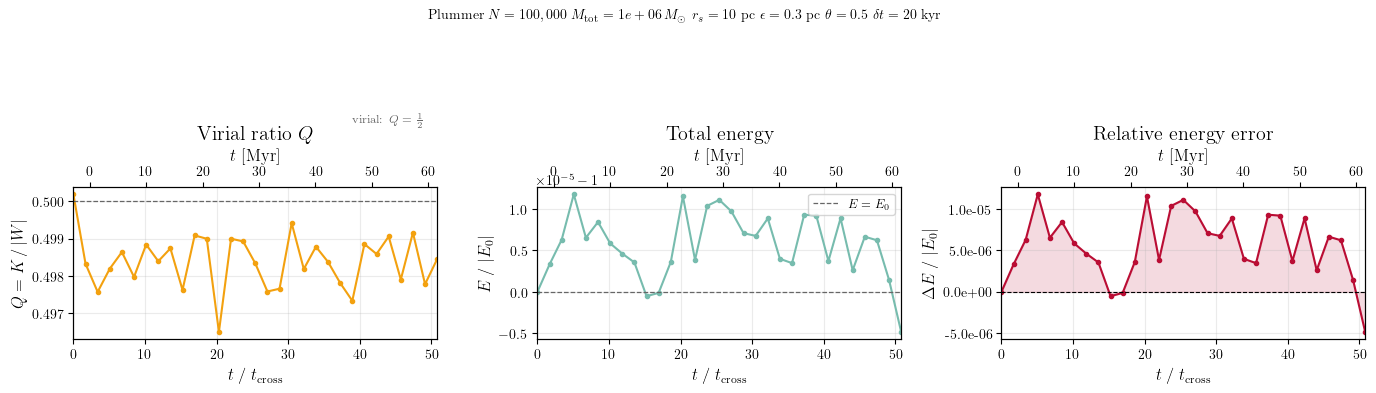

dE/E (final) = -4.823e-06   (< 1e-3 is good for theta = 0.5)
Q    (mean)  = 0.4984   (virial equilibrium: 0.5000)
t_cross = 1.155 Myr   t_total = 50.8 t_cross


In [5]:
reader = ParticleReader(os.path.join(OUTPUT_DIR, "snapshot*.h5"))
snaps  = sorted(reader.Snapshots)
print(f"Found {len(snaps)} snapshots")

t_arr  = np.zeros(len(snaps))
KE_arr = np.zeros(len(snaps))
PE_arr = np.zeros(len(snaps))

mass_cp = cp.full(N, m_particle, dtype=cp.float32)

for i, snap_idx in enumerate(snaps):
    part   = reader.read_snapshot(snap_idx)
    xv     = part.species["dark"]["posvel"].astype(np.float32)
    pos_cp = cp.asarray(xv[:, :3])
    vel_cp = cp.asarray(xv[:, 3:])
    _, phi = tree_gravity_gpu(pos_cp, mass_cp, eps=eps, G=G, theta=theta)
    v2       = float(cp.sum(mass_cp.astype(cp.float64)
                            * cp.sum(vel_cp.astype(cp.float64) ** 2, axis=1)))
    KE_arr[i] = 0.5 * v2
    PE_arr[i] = 0.5 * float(cp.sum(mass_cp.astype(cp.float64)
                                    * phi.astype(cp.float64)))
    t_arr[i]  = part.time   # kpc/(km/s)
    if (i + 1) % 2 == 0 or i == 0 or i == len(snaps) - 1:
        print(f"  {i + 1:3d}/{len(snaps)}  t = {t_arr[i] * GYR * 1e3:6.1f} Myr  "
              f"KE = {KE_arr[i]:.4e}  PE = {PE_arr[i]:.4e}")

E_arr = KE_arr + PE_arr
E0    = E_arr[0]
dE    = (E_arr - E0) / abs(E0)
Q_arr = KE_arr / np.abs(PE_arr)
t_tc  = t_arr / t_cross
t_cross_Myr = t_cross * GYR * 1e3   # correct: multiply by GYR

def _twin_myr(ax):
    ax2 = ax.twiny()
    ax2.set_xlim(np.array(ax.get_xlim()) * t_cross_Myr)
    ax2.set_xlabel(r"$t$ [Myr]")
    return ax2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(t_tc, Q_arr, "-o", color=_cQ, ms=3)
ax.axhline(0.5, color="0.4", ls="--", lw=0.9)
ax.text(t_tc[-1] * 0.96, 0.502, r"virial: $Q = \frac{1}{2}$",
        ha="right", va="bottom", fontsize=8.5, color="0.4")
ax.set_xlabel(r"$t\;/\;t_{\rm cross}$"); ax.set_ylabel(r"$Q = K\,/\,|W|$")
ax.set_title(r"Virial ratio $Q$")
ax.grid(True, alpha=0.25); _twin_myr(ax)

ax = axes[1]
ax.plot(t_tc, E_arr / abs(E0), "-o", color=_cE, ms=3)
ax.axhline(-1.0, color="0.4", ls="--", lw=0.9, label=r"$E = E_0$")
ax.set_xlabel(r"$t\;/\;t_{\rm cross}$"); ax.set_ylabel(r"$E\;/\;|E_0|$")
ax.set_title("Total energy"); ax.legend(fontsize=9)
ax.grid(True, alpha=0.25); _twin_myr(axes[1])

ax = axes[2]
ax.plot(t_tc, dE, "-o", color=_cdE, ms=3)
ax.fill_between(t_tc, dE, alpha=0.15, color=_cdE)
ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel(r"$t\;/\;t_{\rm cross}$"); ax.set_ylabel(r"$\Delta E\;/\;|E_0|$")
ax.set_title("Relative energy error")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1e}"))
ax.grid(True, alpha=0.25); _twin_myr(axes[2])

for ax in axes:
    ax.set_xlim(t_tc[0], t_tc[-1])
fig.suptitle(
    rf"Plummer $N = {N:,}$  $M_{{\rm tot}} = {M_tot:.0e}\,M_\odot$  "
    rf"$r_s = {r_s * 1e3:.0f}$ pc  $\epsilon = {eps * 1e3:.1f}$ pc  "
    rf"$\theta = {theta}$  $\delta t = {dt * GYR * 1e6:.0f}$ kyr",
    fontsize=10)
plt.tight_layout(); plt.show()

print(f"dE/E (final) = {dE[-1]:+.3e}   (< 1e-3 is good for theta = {theta})")
print(f"Q    (mean)  = {Q_arr.mean():.4f}   (virial equilibrium: 0.5000)")
print(f"t_cross = {t_cross_Myr:.3f} Myr   t_total = {t_tc[-1]:.1f} t_cross")

## Initial vs Final Spatial Distribution

Three panels per row:

- **Left**: x–y position density (log hexbin); dashed circle = half-mass radius
- **Centre**: vx–vy velocity space (log hexbin)
- **Right**: r–vr phase space (scatter, coloured by speed) with Plummer escape-velocity envelope


In [ ]:
pos0_np  = xv0_np[:, :3]
vel0_np  = xv0_np[:, 3:]
pos_f_np = xv_final[:, :3]
velf_np  = xv_final[:, 3:]

def _recentre(pos_kpc, m):
    com = (m[:, None] * pos_kpc).sum(0) / m.sum()
    return pos_kpc - com

mass_plot = np.full(N, m_particle)
pos0_rc   = _recentre(pos0_np,  mass_plot)   # kpc
posf_rc   = _recentre(pos_f_np, mass_plot)
r_half_f  = np.median(np.linalg.norm(posf_rc, axis=1))
lim_pc    = 5.0 * max(r_half_0, r_half_f) * 1e3   # plot range [pc]

# Plummer escape-velocity envelope
r_th_pc  = np.linspace(0.1, lim_pc, 400)
v_esc_th = np.sqrt(2 * G * M_tot
                   / np.sqrt((r_th_pc * 1e-3) ** 2 + r_s ** 2))   # km/s

print(f"r_half  initial = {r_half_0 * 1e3:.2f} pc")
print(f"r_half  final   = {r_half_f * 1e3:.2f} pc  "
      f"(delta_r_half / r_half = {(r_half_f - r_half_0) / r_half_0:+.4f})")

CONFIGS = [
    ("Initial", pos0_rc, vel0_np, r_half_0),
    ("Final",   posf_rc, velf_np, r_half_f),
]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 3, figsize=(16, 9),
                          gridspec_kw={"wspace": 0.38, "hspace": 0.38})

for row, (label, pos_rc, vel_np, r_hm) in enumerate(CONFIGS):
    xp   = pos_rc[:, 0] * 1e3; yp = pos_rc[:, 1] * 1e3
    vx   = vel_np[:, 0]; vy = vel_np[:, 1]
    spd  = np.linalg.norm(vel_np, axis=1)
    v_lim = float(np.percentile(spd, 99.5))
    r3_kpc = np.linalg.norm(pos_rc, axis=1)
    r3_kpc = np.where(r3_kpc > 0, r3_kpc, 1e-30)
    r_hat  = pos_rc / r3_kpc[:, None]
    vr     = (r_hat * vel_np).sum(axis=1)
    rp_pc  = r3_kpc * 1e3

    # x-y hexbin
    ax = axes[row, 0]
    hb = ax.hexbin(xp, yp, gridsize=80, bins="log", cmap=_cmap_pos,
                   mincnt=1, linewidths=0.0,
                   extent=[-lim_pc, lim_pc, -lim_pc, lim_pc])
    plt.colorbar(hb, ax=ax, fraction=0.046, pad=0.04
                 ).set_label(r"$\log_{10}(N)$", fontsize=9)
    ax.add_patch(plt.Circle((0, 0), r_hm * 1e3,
                             fill=False, ls="--", lw=1.0, color="w", alpha=0.75))
    ax.set_aspect("equal")
    ax.set_xlim(-lim_pc, lim_pc); ax.set_ylim(-lim_pc, lim_pc)
    ax.set_xlabel(r"$x$ [pc]"); ax.set_ylabel(r"$y$ [pc]")
    ax.set_title(rf"{label}  $x$–$y$  (dashed = $r_{{1/2}}$)")

    # vx-vy hexbin
    ax = axes[row, 1]
    hb2 = ax.hexbin(vx, vy, gridsize=60, bins="log", cmap=_cmap_vel,
                    mincnt=1, linewidths=0.0,
                    extent=[-v_lim, v_lim, -v_lim, v_lim])
    plt.colorbar(hb2, ax=ax, fraction=0.046, pad=0.04
                 ).set_label(r"$\log_{10}(N)$", fontsize=9)
    ax.set_aspect("equal")
    ax.axhline(0, color="0.45", lw=0.5, alpha=0.5)
    ax.axvline(0, color="0.45", lw=0.5, alpha=0.5)
    ax.set_xlabel(r"$v_x$ [km/s]"); ax.set_ylabel(r"$v_y$ [km/s]")
    ax.set_title(rf"{label}  $v_x$–$v_y$")

    # r-vr phase space
    ax = axes[row, 2]
    N_sc = min(len(rp_pc), 50_000)
    idx  = rng.choice(len(rp_pc), N_sc, replace=False)
    ord_ = np.argsort(spd[idx])
    sc   = ax.scatter(rp_pc[idx][ord_], vr[idx][ord_],
                      c=spd[idx][ord_], s=0.6, alpha=0.45, linewidths=0,
                      cmap=_cmap_vel, vmin=0, vmax=v_lim, rasterized=True)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04
                 ).set_label(r"$|\mathbf{v}|$ [km/s]", fontsize=9)
    ax.plot(r_th_pc,  v_esc_th, color="w", ls="--", lw=1.0, alpha=0.8,
            label=r"$v_{\rm esc}(r)$")
    ax.plot(r_th_pc, -v_esc_th, color="w", ls="--", lw=1.0, alpha=0.8)
    ax.axhline(0, color="0.45", lw=0.5, alpha=0.5)
    ax.set_xlim(0, lim_pc); ax.set_ylim(-v_lim, v_lim)
    ax.set_xlabel(r"$r$ [pc]"); ax.set_ylabel(r"$v_r$ [km/s]")
    ax.legend(fontsize=8, framealpha=0.6)

fig.suptitle(
    rf"Plummer  $N = {N:,}$  $M_{{\rm tot}} = {M_tot:.0e}\,M_\odot$  "
    rf"$r_s = {r_s * 1e3:.0f}$ pc  $\epsilon = {eps * 1e3:.1f}$ pc  "
    rf"$\theta = {theta}$  $t_{{\rm total}} = {time_end / t_cross:.0f}\,t_\mathrm{{cross}}$  "
    rf"$\Delta E/|E_0| = {dE[-1]:+.2e}$",
    fontsize=9.5, y=1.01)
plt.tight_layout(); plt.show()


## Half-mass Radius Evolution (optional)

Set  to run a second short simulation tracking r_half every step.  
Adds ~15 s for N = 100 k with 200 steps.


In [ ]:
TRACK_RHALF = False

if TRACK_RHALF:
    from nbody_streams.tree_gpu import TreeGPU
    N_short  = 200
    rhalf_t  = np.zeros(N_short + 1)
    t_s      = np.zeros(N_short + 1)
    mass_s   = cp.full(N, m_particle, dtype=cp.float32)
    pos_s    = cp.asarray(xv0_np[:, :3].astype(np.float32))
    vel_s    = cp.asarray(xv0_np[:, 3:].astype(np.float32))
    tree_s   = TreeGPU(N, eps=0.0, theta=theta, verbose=False)
    acc_s, _ = tree_gravity_gpu(pos_s, mass_s, eps, G=G, theta=theta, tree=tree_s)
    rhalf_t[0] = float(cp.median(cp.linalg.norm(pos_s, axis=1)))
    for step in range(N_short):
        vel_s  = vel_s + (0.5 * dt) * acc_s
        pos_s  = pos_s + dt * vel_s
        acc_s, _ = tree_gravity_gpu(pos_s, mass_s, eps, G=G, theta=theta, tree=tree_s)
        vel_s  = vel_s + (0.5 * dt) * acc_s
        rhalf_t[step + 1] = float(cp.median(cp.linalg.norm(pos_s, axis=1)))
        t_s[step + 1]     = (step + 1) * dt
    tree_s.close()
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(t_s * GYR * 1e3, rhalf_t * 1e3, "C0-")
    ax.axhline(r_half_0 * 1e3, color="k", ls="--", lw=0.8,
               label=r"initial $r_{1/2}$")
    ax.set_xlabel(r"$t$ [Myr]"); ax.set_ylabel(r"$r_{1/2}$ [pc]")
    ax.set_title("Half-mass radius evolution")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Set TRACK_RHALF = True to run the half-mass radius tracking cell.")
